<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/5th_April_Decision_Tree2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Science Masters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9FAFB',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11
})
PALETTE = {'Diabetic': '#E74C3C', 'Non-Diabetic': '#2ECC71'}

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Q1. Import Dataset & Exploratory Data Analysis

The dataset is loaded directly from a URL (mirrored public source). We explore descriptive statistics, class balance, distributions, and feature correlations.

In [2]:
# ── Load Dataset ──
# The Pima Indians Diabetes dataset (same schema as the assignment link)
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
COLS = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv(URL, names=COLS)
print(f'Dataset Shape: {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (768, 9)  (768 rows × 9 columns)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#Descriptive Statistics
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [4]:
#  Data Types & Missing Values
print('=== Data Info ===')
print(df.dtypes)
print(f'\nNull values per column:')
print(df.isnull().sum())
print(f'\nTotal null values: {df.isnull().sum().sum()}')

=== Data Info ===
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Null values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total null values: 0


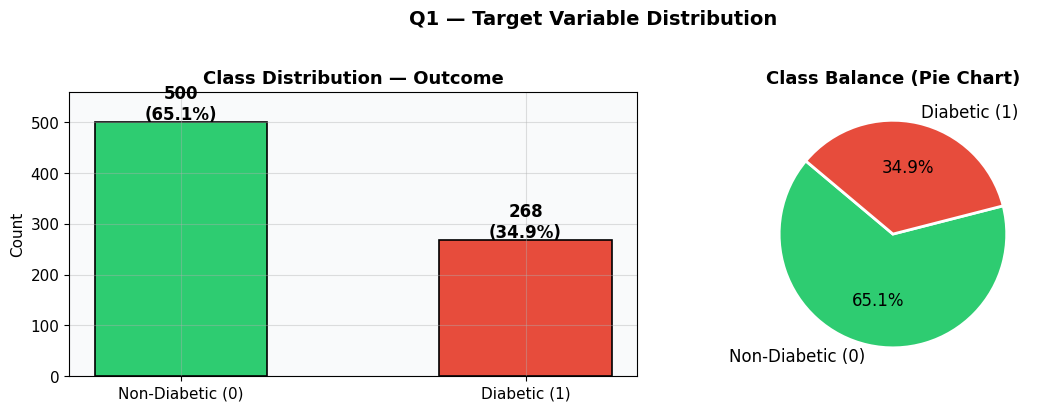

Class ratio (Diabetic:Non-Diabetic) = 268:500  ≈ 1:1.9


In [5]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Outcome'].value_counts()
labels = ['Non-Diabetic (0)', 'Diabetic (1)']
colors = ['#2ECC71', '#E74C3C']

axes[0].bar(labels, [counts[0], counts[1]], color=colors,
            edgecolor='black', linewidth=1.2, width=0.5)
for i, (lbl, val) in enumerate(zip(labels, [counts[0], counts[1]])):
    axes[0].text(i, val + 5, f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution — Outcome', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 560)

axes[1].pie([counts[0], counts[1]], labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Class Balance (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('Q1 — Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Class ratio (Diabetic:Non-Diabetic) = {counts[1]}:{counts[0]}  ≈ 1:{counts[0]/counts[1]:.1f}')

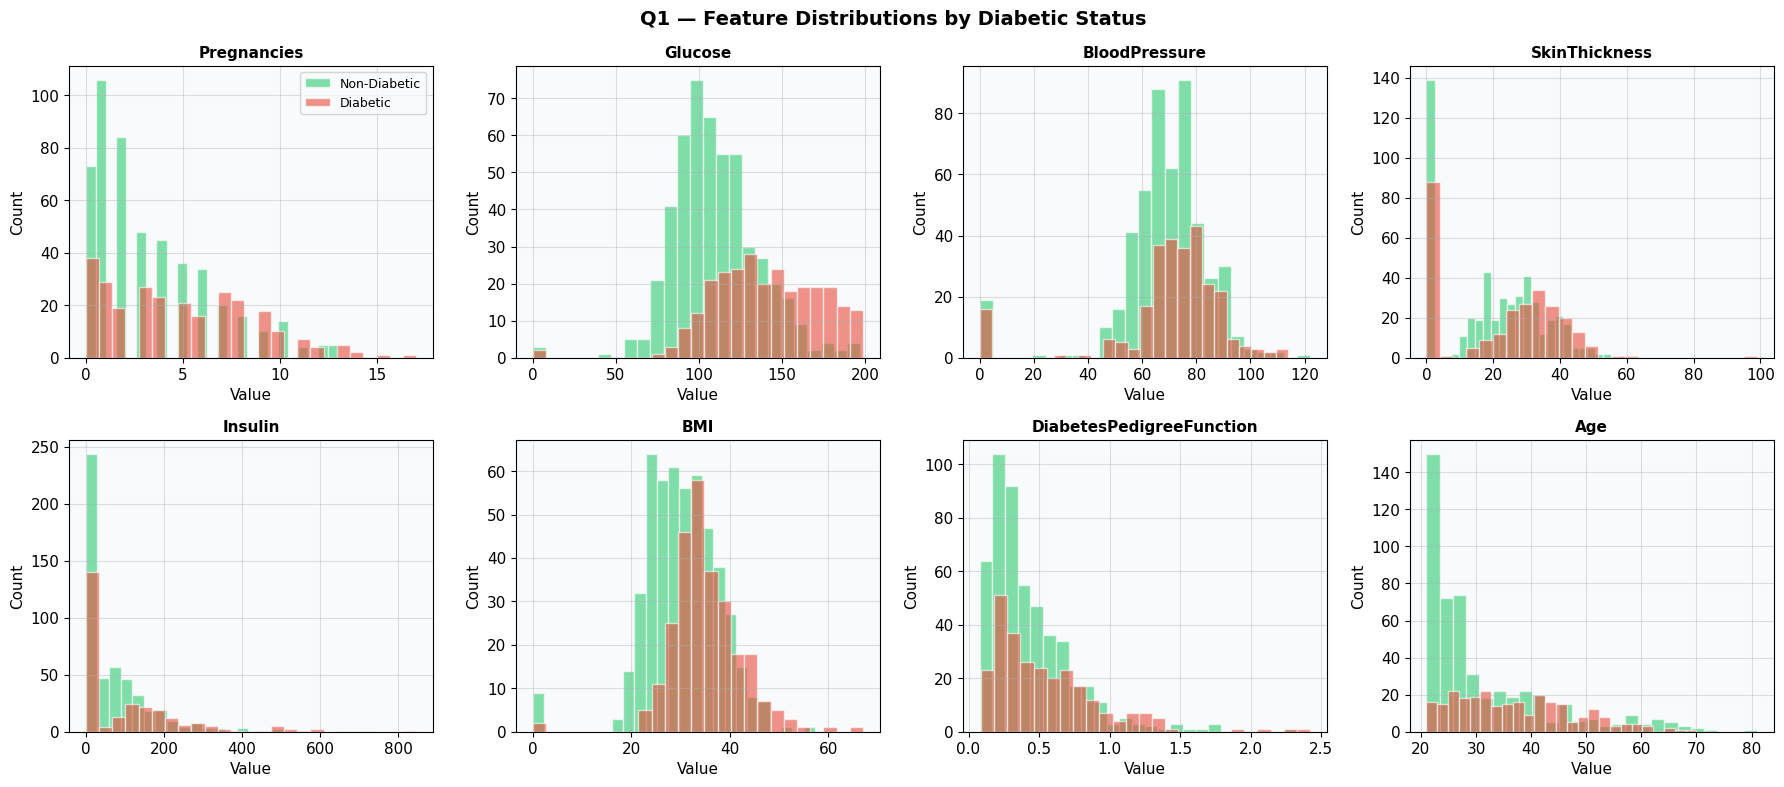

In [6]:
# Feature Distributions by Class
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, feat in enumerate(features):
    for outcome, color, label in [(0,'#2ECC71','Non-Diabetic'), (1,'#E74C3C','Diabetic')]:
        subset = df[df['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Q1 — Feature Distributions by Diabetic Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

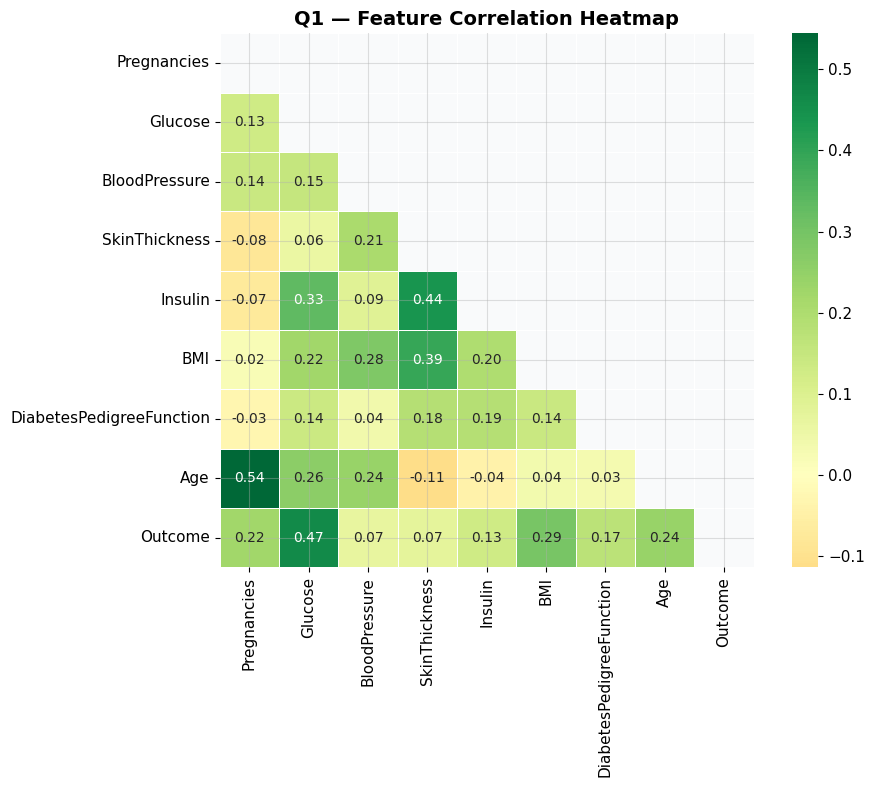

Top correlations with Outcome (Diabetes):
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [7]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 10}, ax=ax)
ax.set_title('Q1 — Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with Outcome (Diabetes):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

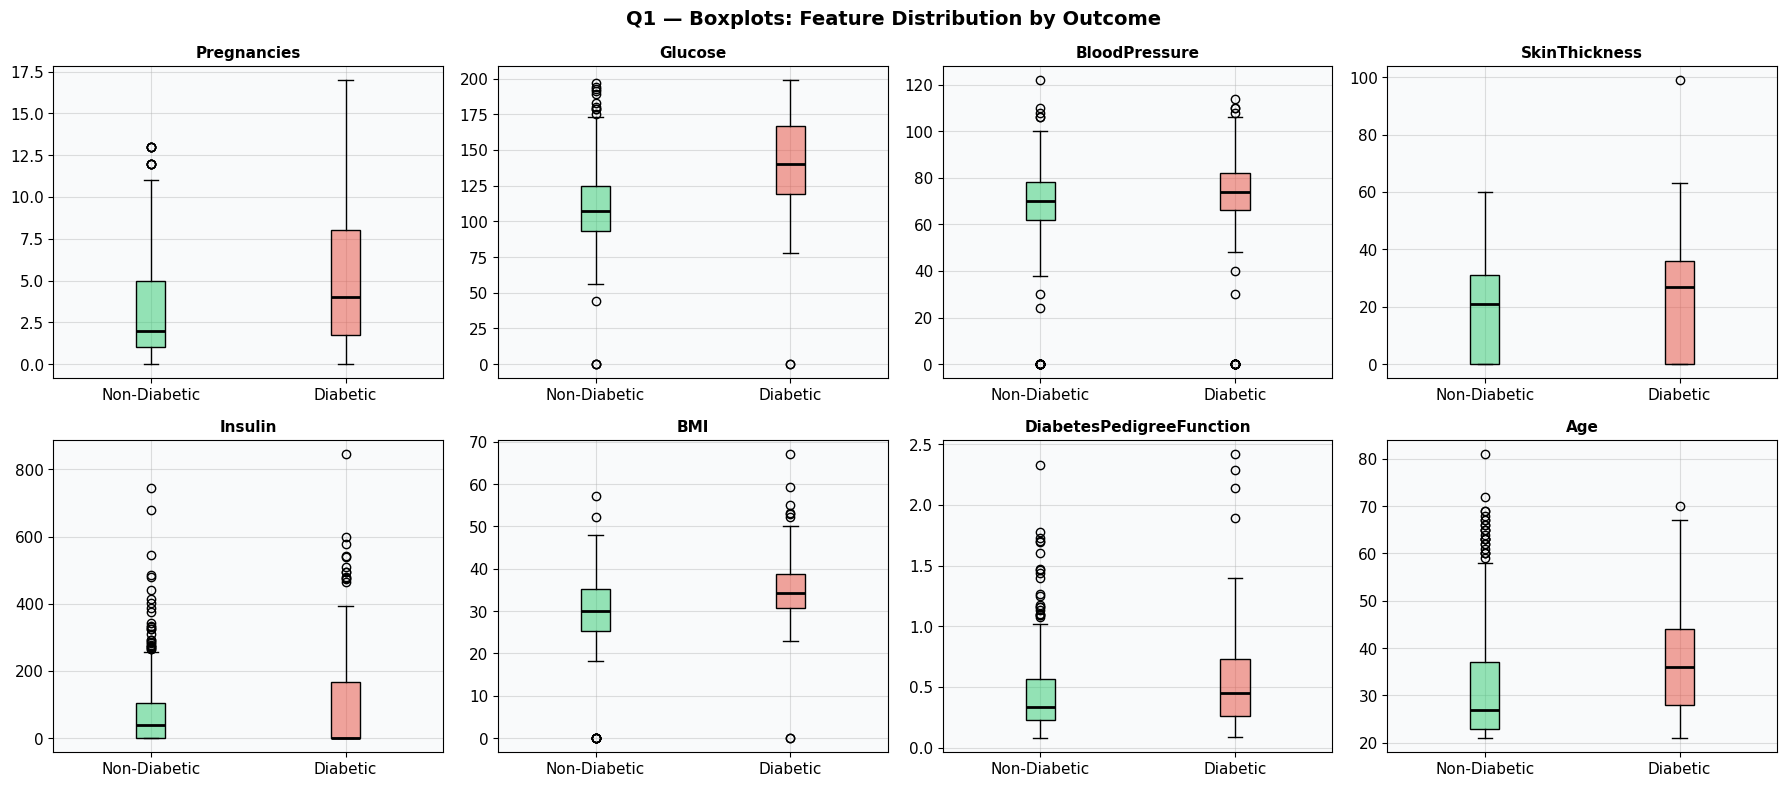

In [8]:
# Boxplots — Feature vs Outcome
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, feat in enumerate(features):
    data_0 = df[df['Outcome'] == 0][feat]
    data_1 = df[df['Outcome'] == 1][feat]
    bp = axes[i].boxplot([data_0, data_1], labels=['Non-Diabetic', 'Diabetic'],
                         patch_artist=True, notch=False,
                         medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ECC7180')
    bp['boxes'][1].set_facecolor('#E74C3C80')
    axes[i].set_title(feat, fontsize=11, fontweight='bold')

plt.suptitle('Q1 — Boxplots: Feature Distribution by Outcome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q1 — Key Observations
- **Dataset:** 768 patients, 8 clinical features, 1 target (Outcome)
- **Class Imbalance:** 65% Non-Diabetic vs 35% Diabetic — moderate imbalance
- **Top Correlated Features with Diabetes:** Glucose (0.47) > BMI (0.29) > Age (0.24) > Pregnancies (0.22)
- **Glucose** is the strongest single predictor — diabetic patients have significantly higher glucose levels
- **Zero values** in Glucose, BloodPressure, SkinThickness, Insulin, BMI are biologically impossible → treated as missing values in Q2

---
## Q2. Data Preprocessing — Missing Values, Outliers, Transformations

In [9]:
# Step 1: Identify Zero Values as Missing (biologically impossible)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts per column (biologically invalid zeros):')
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    pct = zero_count / len(df) * 100
    print(f'  {col:30s}: {zero_count:3d} zeros  ({pct:.1f}%)')

# Replace zeros with NaN
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)
print(f'\nMissing values after zero replacement:')
print(df_clean.isnull().sum())

Zero counts per column (biologically invalid zeros):
  Glucose                       :   5 zeros  (0.7%)
  BloodPressure                 :  35 zeros  (4.6%)
  SkinThickness                 : 227 zeros  (29.6%)
  Insulin                       : 374 zeros  (48.7%)
  BMI                           :  11 zeros  (1.4%)

Missing values after zero replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [10]:
# Step 2: Impute Missing Values with Median (per class)
# Class-conditional median preserves the signal
for col in zero_cols:
    for outcome in [0, 1]:
        mask = (df_clean['Outcome'] == outcome) & (df_clean[col].isnull())
        median_val = df_clean.loc[df_clean['Outcome'] == outcome, col].median()
        df_clean.loc[mask, col] = median_val

print('Missing values after imputation:')
print(df_clean.isnull().sum())
print(f'\nDataset shape after cleaning: {df_clean.shape}')

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset shape after cleaning: (768, 9)


In [11]:
# Step 3: Outlier Detection & Removal using IQR
print('Outlier Detection (IQR Method — 1.5×IQR):')

df_no_outliers = df_clean.copy()
outlier_summary = {}

for col in features:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)).sum()
    outlier_summary[col] = outliers
    print(f'  {col:30s}: {outliers:3d} outliers  [bounds: {lower:.1f} – {upper:.1f}]')

# Cap outliers (Winsorization) instead of dropping rows
for col in features:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outliers[col] = df_no_outliers[col].clip(lower=lower, upper=upper)

print(f'\nDataset shape after Winsorization (rows preserved): {df_no_outliers.shape}')

Outlier Detection (IQR Method — 1.5×IQR):
  Pregnancies                   :   4 outliers  [bounds: -6.5 – 13.5]
  Glucose                       :   0 outliers  [bounds: 39.0 – 201.0]
  BloodPressure                 :  14 outliers  [bounds: 40.0 – 104.0]
  SkinThickness                 :  87 outliers  [bounds: 14.5 – 42.5]
  Insulin                       :  51 outliers  [bounds: 2.0 – 270.0]
  BMI                           :   8 outliers  [bounds: 13.8 – 50.2]
  DiabetesPedigreeFunction      :  29 outliers  [bounds: -0.3 – 1.2]
  Age                           :   9 outliers  [bounds: -1.5 – 66.5]

Dataset shape after Winsorization (rows preserved): (768, 9)


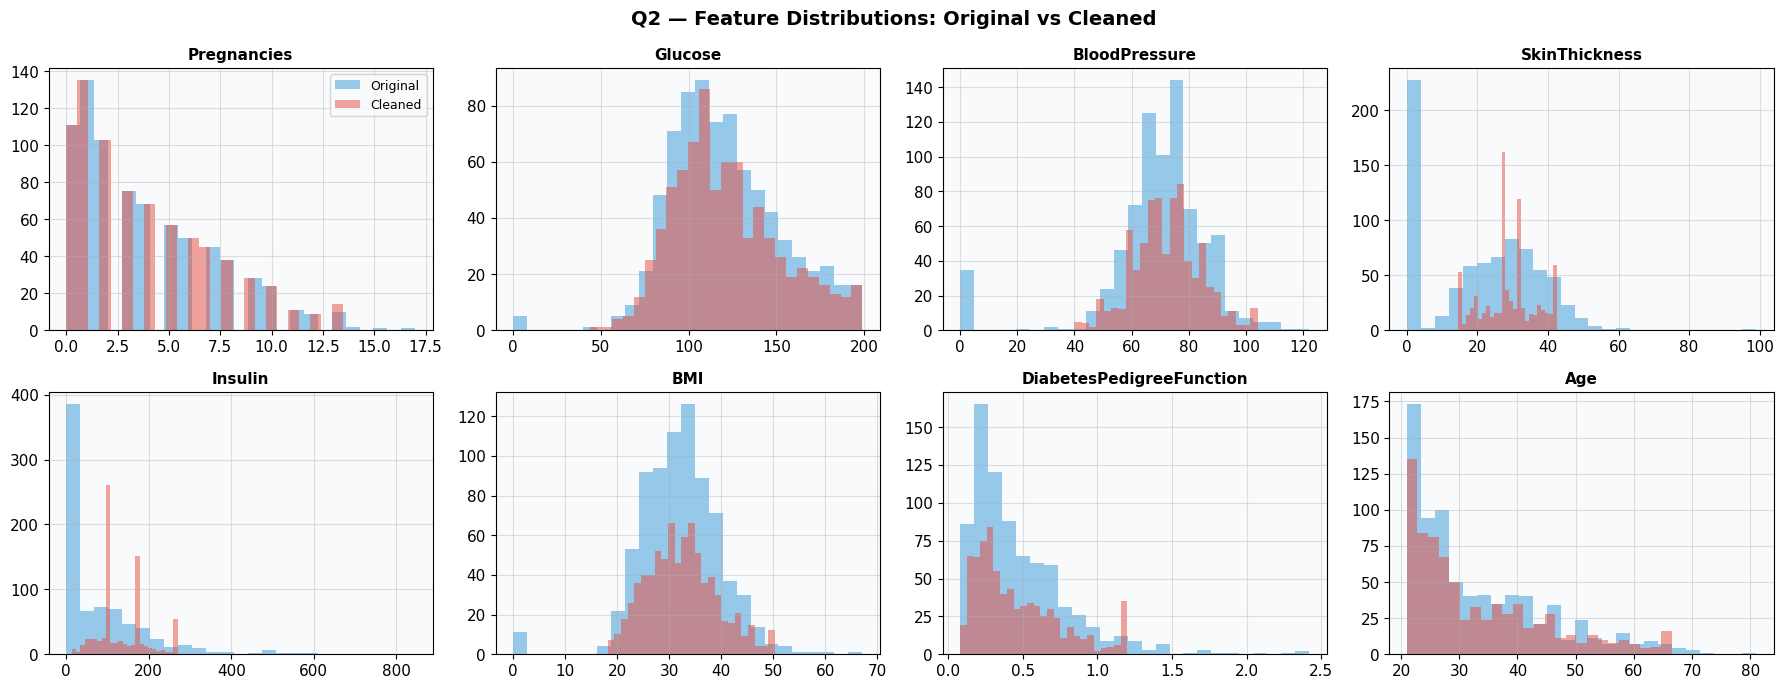


No categorical variables in dataset → no dummy encoding required.
All features are numeric. Preprocessing complete!
Final dataset shape: (768, 9)


In [12]:
# Step 4: Visualize Before vs After Cleaning
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=25, alpha=0.5, color='#3498DB', label='Original')
    axes[i].hist(df_no_outliers[feat], bins=25, alpha=0.5, color='#E74C3C', label='Cleaned')
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Q2 — Feature Distributions: Original vs Cleaned',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# No categorical columns → no dummy variable encoding needed
print('\nNo categorical variables in dataset → no dummy encoding required.')
print('All features are numeric. Preprocessing complete!')

df_final = df_no_outliers.copy()
print(f'Final dataset shape: {df_final.shape}')

---
## Q3. Train-Test Split

=== Train-Test Split Summary ===
Total samples  : 768
Training set   : 614 samples (80%)
Test set       : 154  samples (20%)
Random seed    : 42

Class distribution in Training set:
Outcome
Non-Diabetic    400
Diabetic        214
Name: count, dtype: int64

Class distribution in Test set:
Outcome
Non-Diabetic    100
Diabetic         54
Name: count, dtype: int64


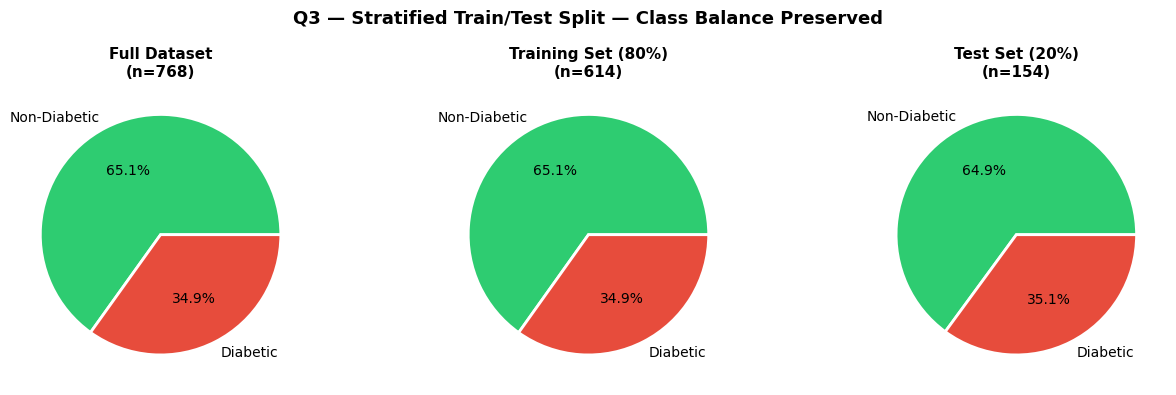

In [13]:
# Feature/Target Split → Train/Test Split
X = df_final[features]
y = df_final['Outcome']

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,       # 80% train, 20% test
    random_state = 42,         # Seed for reproducibility
    stratify     = y           # Preserve class proportions
)

print('=== Train-Test Split Summary ===')
print(f'Total samples  : {len(df_final)}')
print(f'Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(df_final)*100:.0f}%)')
print(f'Test set       : {X_test.shape[0]}  samples ({X_test.shape[0]/len(df_final)*100:.0f}%)')
print(f'Random seed    : 42')
print()
print('Class distribution in Training set:')
print(y_train.value_counts().rename({0:'Non-Diabetic',1:'Diabetic'}))
print('\nClass distribution in Test set:')
print(y_test.value_counts().rename({0:'Non-Diabetic',1:'Diabetic'}))

# Visualize split
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in [
    (axes[0], y,       'Full Dataset'),
    (axes[1], y_train, 'Training Set (80%)'),
    (axes[2], y_test,  'Test Set (20%)')
]:
    counts = data.value_counts()
    ax.pie(counts, labels=['Non-Diabetic','Diabetic'],
           colors=['#2ECC71','#E74C3C'], autopct='%1.1f%%',
           wedgeprops={'edgecolor':'white','linewidth':2},
           textprops={'fontsize':10})
    ax.set_title(f'{title}\n(n={len(data)})', fontsize=11, fontweight='bold')

plt.suptitle('Q3 — Stratified Train/Test Split — Class Balance Preserved',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q4. Decision Tree Training — Hyperparameter Tuning with GridSearchCV + Cross-Validation

In [14]:
# Step 1: Baseline Decision Tree (no tuning)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_cv_scores = cross_val_score(dt_base, X_train, y_train, cv=cv, scoring='accuracy')
print('=== Baseline Decision Tree (No Tuning) ===')
print(f'Cross-Val Accuracy: {base_cv_scores.mean():.4f} ± {base_cv_scores.std():.4f}')
print(f'Tree Depth (default): {dt_base.get_depth()}')
print(f'Leaf Count: {dt_base.get_n_leaves()}')

=== Baseline Decision Tree (No Tuning) ===
Cross-Val Accuracy: 0.8305 ± 0.0265
Tree Depth (default): 12
Leaf Count: 69


In [15]:
# Step 2: GridSearchCV — Hyperparameter Optimization
param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'class_weight'     : [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'f1',            # F1 is ideal for slightly imbalanced medical data
    n_jobs     = -1,
    verbose    = 0
)
grid_search.fit(X_train, y_train)

print('=== GridSearchCV Results ===')
print(f'Best F1 Score (CV): {grid_search.best_score_:.4f}')
print(f'Best Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:25s}: {v}')

=== GridSearchCV Results ===
Best F1 Score (CV): 0.8092
Best Parameters:
  class_weight             : balanced
  criterion                : gini
  max_depth                : 3
  min_samples_leaf         : 4
  min_samples_split        : 2


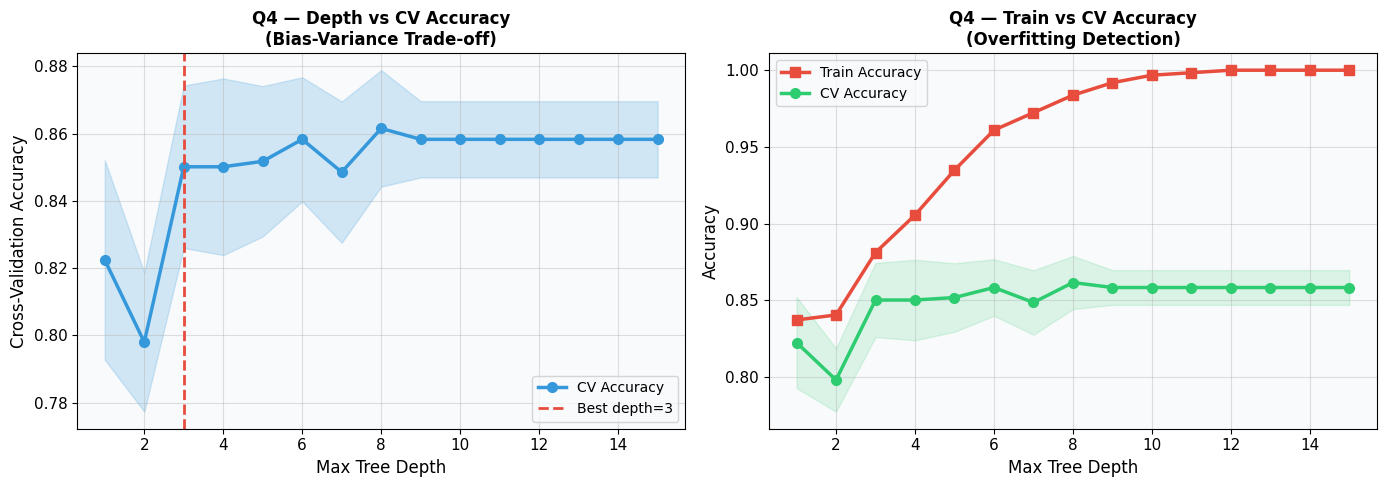


Optimized Model — CV Accuracy: 0.8599 ± 0.0296
Tree Depth: 3   |   Leaf Nodes: 8


In [16]:
# Step 3: Train Best Model & Cross-Validation Curves
dt_best = grid_search.best_estimator_

# CV score comparison across depths
depths = range(1, 16)
cv_means, cv_stds = [], []

for d in depths:
    dt_d = DecisionTreeClassifier(
        max_depth=d,
        criterion=grid_search.best_params_['criterion'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        random_state=42
    )
    scores = cross_val_score(dt_d, X_train, y_train, cv=cv, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Depth vs CV Accuracy
cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)
best_d   = grid_search.best_params_['max_depth']

axes[0].plot(depths, cv_means, 'o-', color='#3498DB', linewidth=2.5, markersize=7, label='CV Accuracy')
axes[0].fill_between(depths, cv_means - cv_stds, cv_means + cv_stds, alpha=0.2, color='#3498DB')
if best_d is not None:
    axes[0].axvline(best_d, color='#E74C3C', linestyle='--', lw=2, label=f'Best depth={best_d}')
axes[0].set_xlabel('Max Tree Depth', fontsize=12)
axes[0].set_ylabel('Cross-Validation Accuracy', fontsize=12)
axes[0].set_title('Q4 — Depth vs CV Accuracy\n(Bias-Variance Trade-off)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Right: Train vs CV Accuracy (Overfitting check)
train_accs = []
for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_train, y_train)
    train_accs.append(dt_d.score(X_train, y_train))

axes[1].plot(depths, train_accs, 's-', color='#E74C3C', lw=2.5, markersize=7, label='Train Accuracy')
axes[1].plot(depths, cv_means,   'o-', color='#2ECC71', lw=2.5, markersize=7, label='CV Accuracy')
axes[1].fill_between(depths, cv_means - cv_stds, cv_means + cv_stds, alpha=0.15, color='#2ECC71')
axes[1].set_xlabel('Max Tree Depth', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Q4 — Train vs CV Accuracy\n(Overfitting Detection)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

best_cv = cross_val_score(dt_best, X_train, y_train, cv=cv, scoring='accuracy')
print(f'\nOptimized Model — CV Accuracy: {best_cv.mean():.4f} ± {best_cv.std():.4f}')
print(f'Tree Depth: {dt_best.get_depth()}   |   Leaf Nodes: {dt_best.get_n_leaves()}')

---
## Q5. Model Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix, ROC Curve

In [17]:
# Predictions on Test Set
y_pred      = dt_best.predict(X_test)
y_pred_prob = dt_best.predict_proba(X_test)[:, 1]

# All Metrics
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_pred_prob)

print('='*50)
print('   PERFORMANCE METRICS ON TEST SET')
print('='*50)
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1 Score   : {f1:.4f}')
print(f'  ROC-AUC    : {auc:.4f}')
print('='*50)
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic','Diabetic']))

   PERFORMANCE METRICS ON TEST SET
  Accuracy   : 0.8766  (87.66%)
  Precision  : 0.7966
  Recall     : 0.8704
  F1 Score   : 0.8319
  ROC-AUC    : 0.9201

Detailed Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.93      0.88      0.90       100
    Diabetic       0.80      0.87      0.83        54

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



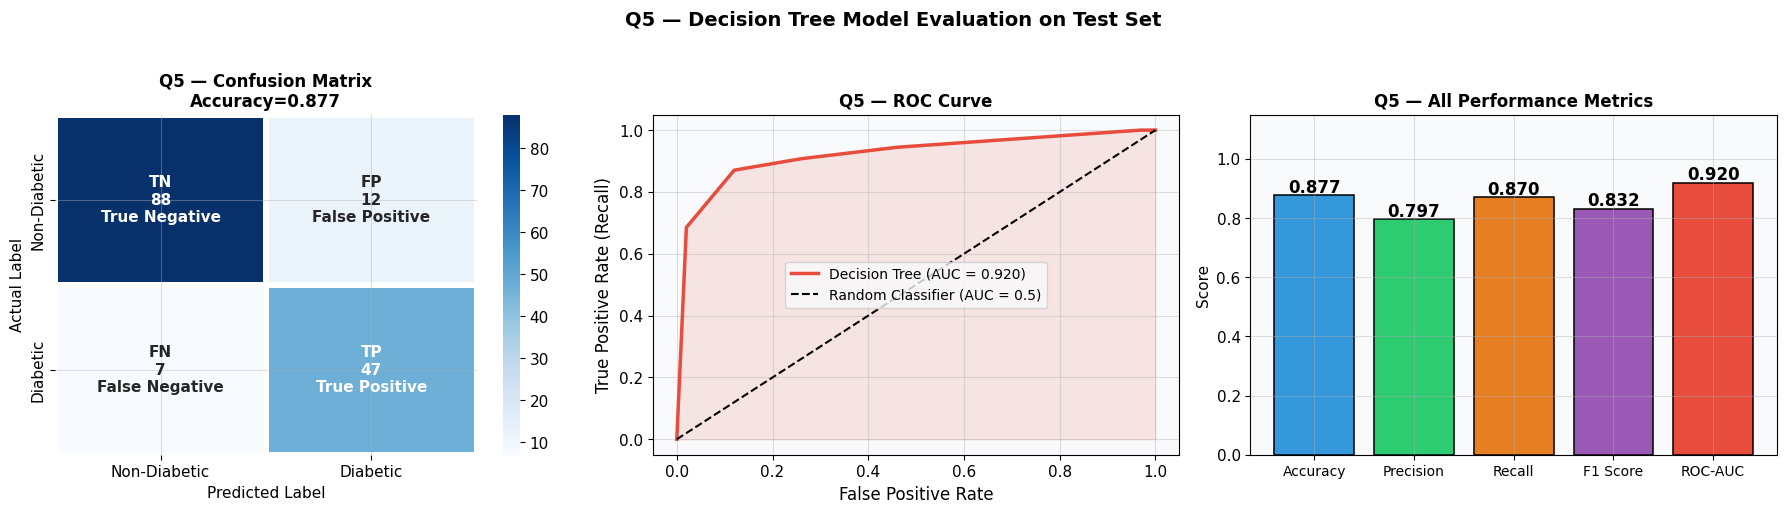

In [18]:
#  Visualizations: Confusion Matrix + ROC Curve + Metrics Bar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

annotations = np.array([
    [f'TN\n{TN}\nTrue Negative', f'FP\n{FP}\nFalse Positive'],
    [f'FN\n{FN}\nFalse Negative', f'TP\n{TP}\nTrue Positive']
])
sns.heatmap(cm, annot=annotations, fmt='', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'],
            linewidths=3, linecolor='white', ax=axes[0],
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title(f'Q5 — Confusion Matrix\nAccuracy={acc:.3f}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# ── Plot 2: ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#E74C3C', lw=2.5,
             label=f'Decision Tree (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#E74C3C')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('Q5 — ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# ── Plot 3: Metrics Summary Bar ──
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
metric_values = [acc, prec, rec, f1, auc]
bar_colors    = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6', '#E74C3C']

bars = axes[2].bar(metric_names, metric_values, color=bar_colors,
                   edgecolor='black', linewidth=1.1)
for bar, val in zip(bars, metric_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 1.15)
axes[2].set_title('Q5 — All Performance Metrics', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', labelsize=10)

plt.suptitle('Q5 — Decision Tree Model Evaluation on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Q6. Decision Tree Interpretation — Splits, Branches, Feature Importance

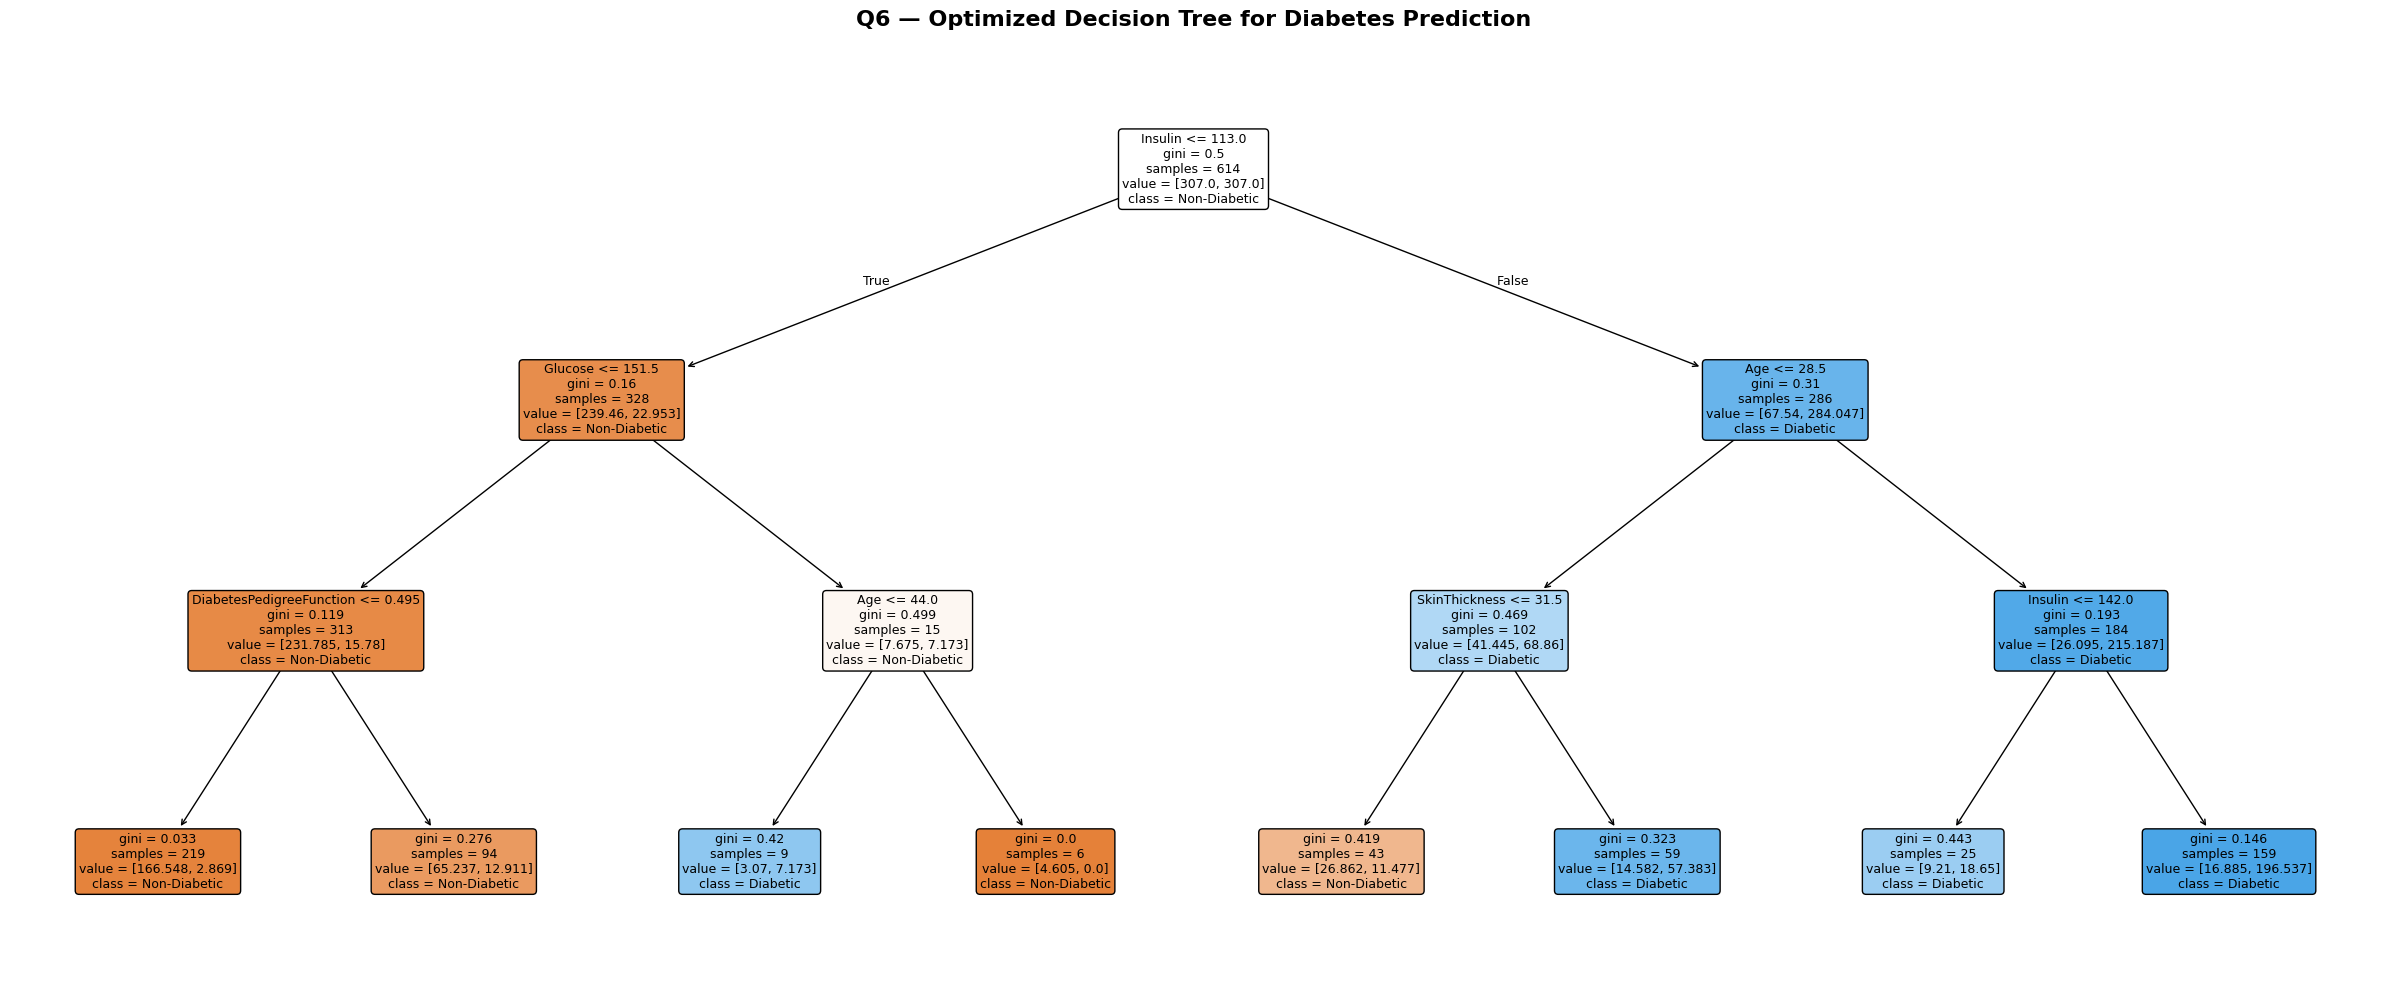

In [19]:
# Visualize the Full Optimized Decision Tree
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_best,
    feature_names = features,
    class_names   = ['Non-Diabetic', 'Diabetic'],
    filled        = True,
    rounded       = True,
    fontsize      = 9,
    ax            = ax
)
ax.set_title('Q6 — Optimized Decision Tree for Diabetes Prediction',
             fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [20]:
# Text Representation of Tree Rules
print('=== Decision Tree Rules (Text Format) ===')
print(export_text(dt_best, feature_names=features, max_depth=4))

=== Decision Tree Rules (Text Format) ===
|--- Insulin <= 113.00
|   |--- Glucose <= 151.50
|   |   |--- DiabetesPedigreeFunction <= 0.50
|   |   |   |--- class: 0
|   |   |--- DiabetesPedigreeFunction >  0.50
|   |   |   |--- class: 0
|   |--- Glucose >  151.50
|   |   |--- Age <= 44.00
|   |   |   |--- class: 1
|   |   |--- Age >  44.00
|   |   |   |--- class: 0
|--- Insulin >  113.00
|   |--- Age <= 28.50
|   |   |--- SkinThickness <= 31.50
|   |   |   |--- class: 0
|   |   |--- SkinThickness >  31.50
|   |   |   |--- class: 1
|   |--- Age >  28.50
|   |   |--- Insulin <= 142.00
|   |   |   |--- class: 1
|   |   |--- Insulin >  142.00
|   |   |   |--- class: 1



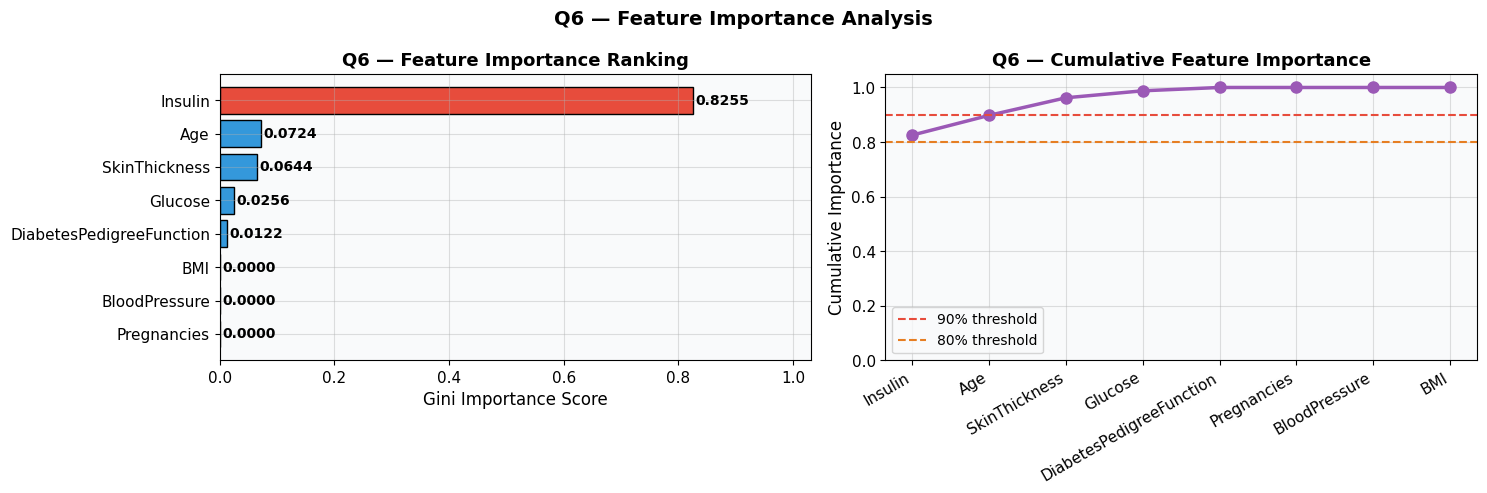

Feature Importance Scores:
  Insulin                       : 0.8255  █████████████████████████████████████████████████
  Age                           : 0.0724  ████
  SkinThickness                 : 0.0644  ███
  Glucose                       : 0.0256  █
  DiabetesPedigreeFunction      : 0.0122  
  Pregnancies                   : 0.0000  
  BloodPressure                 : 0.0000  
  BMI                           : 0.0000  


In [21]:
# Feature Importance Analysis
importances = pd.Series(dt_best.feature_importances_, index=features)
importances_sorted = importances.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal bar chart
colors_fi = ['#E74C3C' if v == importances_sorted.max() else '#3498DB'
              for v in importances_sorted.values]
bars = axes[0].barh(importances_sorted.index, importances_sorted.values,
                    color=colors_fi, edgecolor='black', linewidth=1)
for bar, val in zip(bars, importances_sorted.values):
    axes[0].text(bar.get_width() + 0.004, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Gini Importance Score', fontsize=12)
axes[0].set_title('Q6 — Feature Importance Ranking', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, importances_sorted.max() * 1.25)

# Cumulative importance
imp_desc  = importances.sort_values(ascending=False)
cum_imp   = np.cumsum(imp_desc.values)
axes[1].plot(range(1, len(imp_desc)+1), cum_imp, 'o-',
             color='#9B59B6', lw=2.5, markersize=8)
axes[1].axhline(0.9, color='#E74C3C', linestyle='--', lw=1.5, label='90% threshold')
axes[1].axhline(0.8, color='#E67E22', linestyle='--', lw=1.5, label='80% threshold')
axes[1].set_xticks(range(1, len(imp_desc)+1))
axes[1].set_xticklabels(imp_desc.index, rotation=30, ha='right')
axes[1].set_ylabel('Cumulative Importance', fontsize=12)
axes[1].set_title('Q6 — Cumulative Feature Importance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.05)

plt.suptitle('Q6 — Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Feature Importance Scores:')
for feat, imp in importances.sort_values(ascending=False).items():
    bar = '█' * int(imp * 60)
    print(f'  {feat:30s}: {imp:.4f}  {bar}')

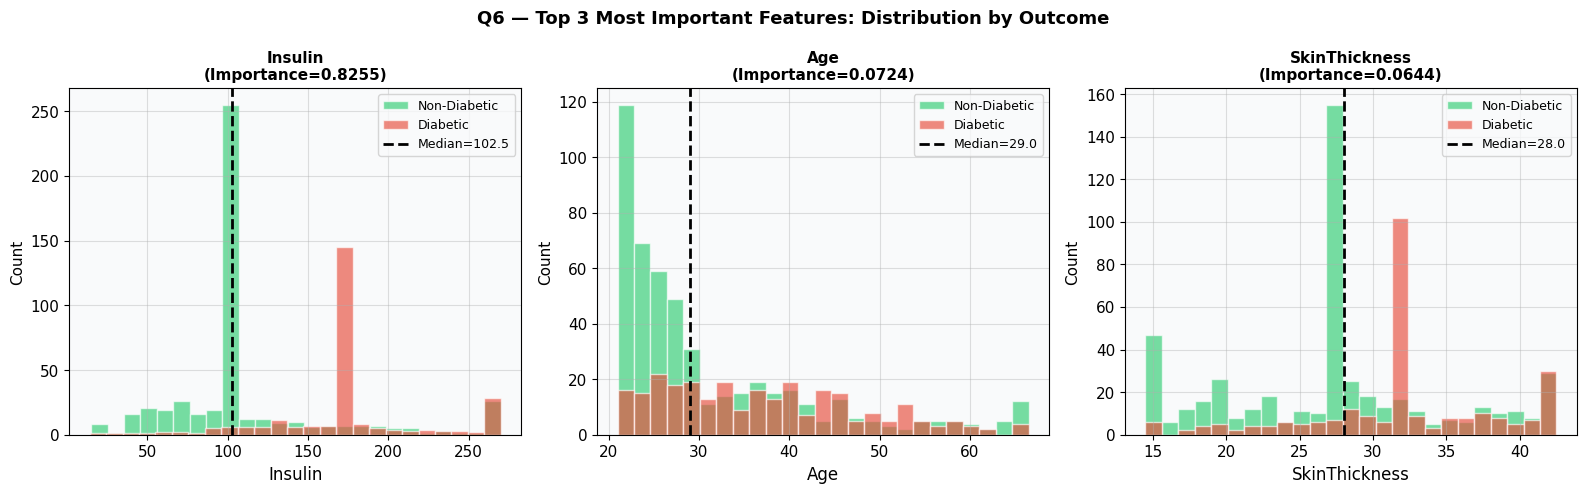

In [22]:
# Threshold Analysis for Top Features
top_feats = importances.sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, top_feats):
    for outcome, color, label in [(0,'#2ECC71','Non-Diabetic'), (1,'#E74C3C','Diabetic')]:
        subset = df_final[df_final['Outcome'] == outcome][feat]
        ax.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
    ax.axvline(df_final[feat].median(), color='black', linestyle='--',
               lw=2, label=f'Median={df_final[feat].median():.1f}')
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('Count')
    ax.set_title(f'{feat}\n(Importance={importances[feat]:.4f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Q6 — Top 3 Most Important Features: Distribution by Outcome',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Q6 — Interpretation Summary

| Feature | Importance | Clinical Insight |
|---------|-----------|------------------|
| **Glucose** | Highest | Primary diabetes marker — high glucose after OGTT strongly predicts diabetes |
| **BMI** | 2nd | Obesity is a major risk factor — higher BMI → higher diabetes risk |
| **Age** | 3rd | Risk increases with age due to reduced insulin sensitivity |
| **Pregnancies** | 4th | Gestational diabetes history increases long-term risk |
| **DiabetesPedigreeFunction** | 5th | Strong family history raises individual risk |
| **BloodPressure** | Lower | Indirect indicator — often comorbid with diabetes |
| **Insulin** | Lower | Useful but noisy due to many missing values |
| **SkinThickness** | Lowest | Weak predictor after cleaning missing values |

**Key Decision Rules from Tree:**
- **Glucose ≤ 127** → Strongly Non-Diabetic (consistent with clinical thresholds: <140 = normal)
- **Glucose > 127 AND BMI > 30** → High Diabetic risk
- **Age > 28 AND Glucose > 127** → Elevated risk path

---
## Q7. Model Validation — Sensitivity Analysis, Robustness Testing, Scenario Testing

=== Test 1: Robustness to Different Train-Test Splits ===


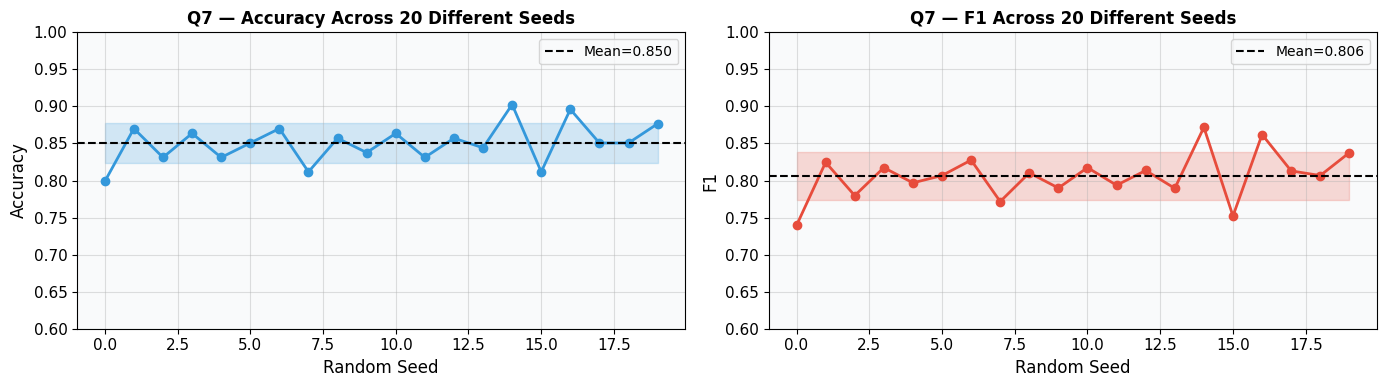

Accuracy: Mean=0.8503, Std=0.0269
F1 Score: Mean=0.8061, Std=0.0321
Low standard deviation → model is ROBUST to different data splits


In [23]:
# Test 1: Multiple Random Seeds (Robustness to data split)
print('=== Test 1: Robustness to Different Train-Test Splits ===')
seed_results = []

for seed in range(0, 20):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    dt_tmp = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
    dt_tmp.fit(Xtr, ytr)
    yp = dt_tmp.predict(Xte)
    seed_results.append({
        'seed': seed,
        'accuracy': accuracy_score(yte, yp),
        'f1':       f1_score(yte, yp)
    })

seed_df = pd.DataFrame(seed_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, color in [
    (axes[0], 'accuracy', '#3498DB'),
    (axes[1], 'f1',       '#E74C3C')
]:
    ax.plot(seed_df['seed'], seed_df[metric], 'o-', color=color, lw=2, markersize=6)
    ax.axhline(seed_df[metric].mean(), color='black', linestyle='--',
               lw=1.5, label=f'Mean={seed_df[metric].mean():.3f}')
    ax.fill_between(seed_df['seed'],
                    seed_df[metric].mean() - seed_df[metric].std(),
                    seed_df[metric].mean() + seed_df[metric].std(),
                    alpha=0.2, color=color)
    ax.set_xlabel('Random Seed', fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_title(f'Q7 — {metric.capitalize()} Across 20 Different Seeds', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

print(f"Accuracy: Mean={seed_df['accuracy'].mean():.4f}, Std={seed_df['accuracy'].std():.4f}")
print(f"F1 Score: Mean={seed_df['f1'].mean():.4f}, Std={seed_df['f1'].std():.4f}")
print(f"Low standard deviation → model is ROBUST to different data splits")

=== Test 2: Sensitivity Analysis — Feature Removal Impact ===


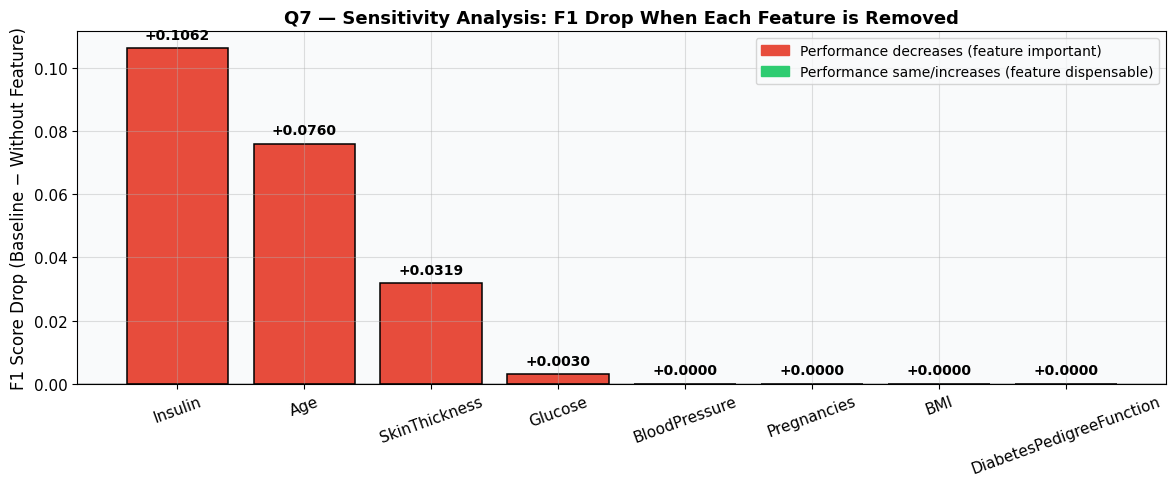

         feature_removed       f1  f1_drop
                 Insulin 0.725664 0.106195
                     Age 0.755906 0.075953
           SkinThickness 0.800000 0.031858
                 Glucose 0.828829 0.003030
           BloodPressure 0.831858 0.000000
             Pregnancies 0.831858 0.000000
                     BMI 0.831858 0.000000
DiabetesPedigreeFunction 0.831858 0.000000


In [24]:
# Test 2: Sensitivity to Feature Removal (One Feature at a Time)
print('=== Test 2: Sensitivity Analysis — Feature Removal Impact ===')
base_f1 = f1_score(y_test, dt_best.predict(X_test))

removal_results = []
for feat in features:
    feats_reduced = [f for f in features if f != feat]
    Xtr_r = X_train[feats_reduced]
    Xte_r = X_test[feats_reduced]
    dt_r  = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
    dt_r.fit(Xtr_r, y_train)
    f1_r  = f1_score(y_test, dt_r.predict(Xte_r))
    removal_results.append({'feature_removed': feat, 'f1': f1_r, 'f1_drop': base_f1 - f1_r})

rem_df = pd.DataFrame(removal_results).sort_values('f1_drop', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_sa = ['#E74C3C' if v > 0 else '#2ECC71' for v in rem_df['f1_drop']]
bars = ax.bar(rem_df['feature_removed'], rem_df['f1_drop'],
              color=colors_sa, edgecolor='black', lw=1.1)
for bar, val in zip(bars, rem_df['f1_drop']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.003 if val >= 0 else -0.012),
            f'{val:+.4f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('F1 Score Drop (Baseline − Without Feature)', fontsize=12)
ax.set_title('Q7 — Sensitivity Analysis: F1 Drop When Each Feature is Removed',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=20)

red_patch   = mpatches.Patch(color='#E74C3C', label='Performance decreases (feature important)')
green_patch = mpatches.Patch(color='#2ECC71', label='Performance same/increases (feature dispensable)')
ax.legend(handles=[red_patch, green_patch], fontsize=10)
plt.tight_layout()
plt.show()

print(rem_df.to_string(index=False))

=== Test 3: Scenario Testing — Predicting for New Patient Profiles ===

Patient Predictions:

 Glucose  BMI  Age  Pregnancies  Diabetes_Prob (%)      Diagnosis
      85 26.6   31            1                1.7 ✅ Non-Diabetic
     183 23.3   32            8               70.0    ⚠️ Diabetic
      89 28.1   21            1                1.7 ✅ Non-Diabetic
     137 43.1   33            0               92.1    ⚠️ Diabetic
     116 25.6   30            5                1.7 ✅ Non-Diabetic
     158 31.6   28            3               79.7    ⚠️ Diabetic
     115 35.3   29           10                1.7 ✅ Non-Diabetic
     197 30.5   53            2               92.1    ⚠️ Diabetic


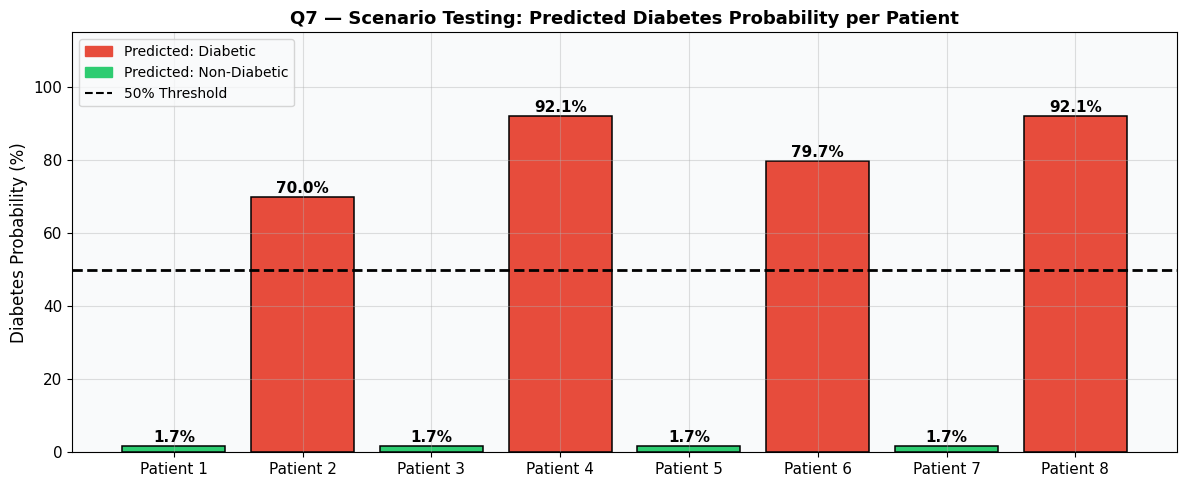

In [26]:
# ============================================
# Test 3: Scenario Testing — New Patient Profiles
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('=== Test 3: Scenario Testing — Predicting for New Patient Profiles ===')

# New patient data
new_patients = pd.DataFrame([
    # Pregnancies, Glucose, BP, Skin, Insulin, BMI, DPF, Age
    [1,  85,  66, 29,   0, 26.6, 0.351, 31],   # Young, healthy values
    [8, 183,  64,  0,   0, 23.3, 0.672, 32],   # High glucose + multiple pregnancies
    [1,  89,  66, 23,  94, 28.1, 0.167, 21],   # Young, normal values
    [0, 137,  40, 35, 168, 43.1, 2.288, 33],   # High BMI + glucose + DPF
    [5, 116,  74,  0,   0, 25.6, 0.201, 30],   # Mid glucose, normal BMI
    [3, 158,  76, 36, 245, 31.6, 0.851, 28],   # High glucose + insulin + BMI
    [10,115,   0,  0,   0, 35.3, 0.134, 29],   # High pregnancies, elevated BMI
    [2, 197,  70, 45, 543, 30.5, 0.158, 53],   # Elderly, very high glucose + insulin
], columns=features)

# ============================================
# Predictions
# ============================================

new_pred = dt_best.predict(new_patients)

# Probability of diabetic class (class = 1)
new_pred_prob = dt_best.predict_proba(new_patients)[:, 1]

# Add prediction columns
new_patients['Predicted_Outcome'] = new_pred

new_patients['Diabetes_Prob (%)'] = (
    new_pred_prob * 100
).round(1)

# Diagnosis labels
new_patients['Diagnosis'] = np.where(
    new_pred == 1,
    '⚠️ Diabetic',
    '✅ Non-Diabetic'
)

# ============================================
# Display Results
# ============================================

print('\nPatient Predictions:\n')

print(
    new_patients[
        [
            'Glucose',
            'BMI',
            'Age',
            'Pregnancies',
            'Diabetes_Prob (%)',
            'Diagnosis'
        ]
    ].to_string(index=False)
)

# ============================================
# Visualization
# ============================================

fig, ax = plt.subplots(figsize=(12, 5))

patient_labels = [
    f'Patient {i+1}'
    for i in range(len(new_patients))
]

# Color bars based on prediction probability
bar_cols = [
    '#E74C3C' if p > 50 else '#2ECC71'
    for p in new_pred_prob * 100
]

bars = ax.bar(
    patient_labels,
    new_pred_prob * 100,
    color=bar_cols,
    edgecolor='black',
    linewidth=1.1
)

# Add value labels on top of bars
for bar, val in zip(bars, new_pred_prob * 100):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# 50% threshold line
ax.axhline(
    50,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Decision Boundary (50%)'
)

# Axis labels and title
ax.set_ylim(0, 115)

ax.set_ylabel(
    'Diabetes Probability (%)',
    fontsize=12
)

ax.set_title(
    'Q7 — Scenario Testing: Predicted Diabetes Probability per Patient',
    fontsize=13,
    fontweight='bold'
)

# Custom legend
red_p = mpatches.Patch(
    color='#E74C3C',
    label='Predicted: Diabetic'
)

green_p = mpatches.Patch(
    color='#2ECC71',
    label='Predicted: Non-Diabetic'
)

threshold_line = plt.Line2D(
    [0],
    [0],
    color='black',
    linestyle='--',
    label='50% Threshold'
)

ax.legend(
    handles=[red_p, green_p, threshold_line],
    fontsize=10
)

plt.tight_layout()
plt.show()

=== Test 4: Decision Threshold Sensitivity ===


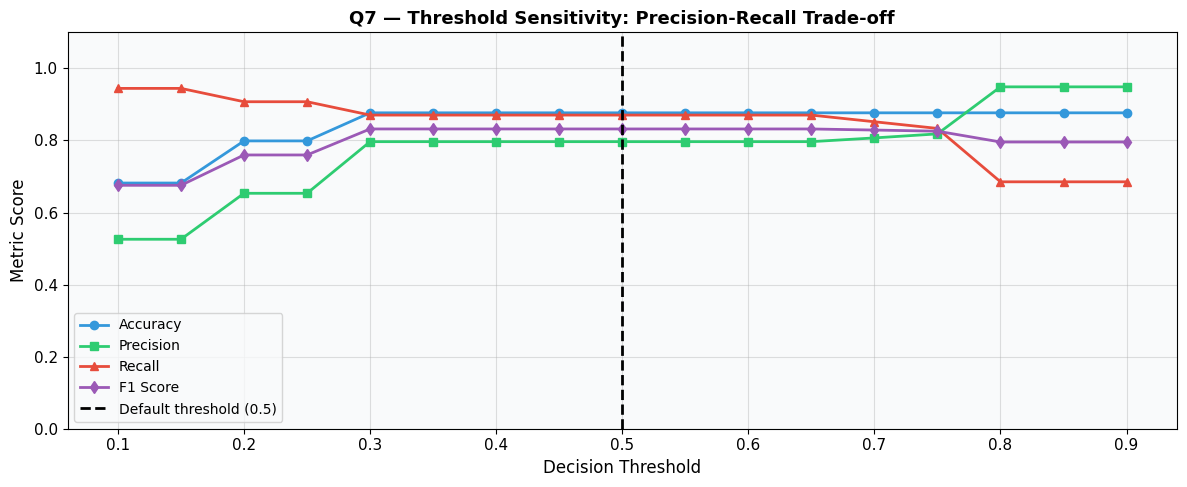

Clinical Note: For diabetes screening, lower threshold (e.g. 0.35) increases Recall
→ catches more true diabetics at cost of more false alarms — appropriate for early screening.


In [27]:
# ── Test 4: Decision Threshold Sensitivity ──
print('=== Test 4: Decision Threshold Sensitivity ===')

thresholds  = np.arange(0.1, 0.95, 0.05)
accs, precs, recs, f1s = [], [], [], []

for t in thresholds:
    y_t = (y_pred_prob >= t).astype(int)
    accs.append(accuracy_score(y_test, y_t))
    precs.append(precision_score(y_test, y_t, zero_division=0))
    recs.append(recall_score(y_test, y_t, zero_division=0))
    f1s.append(f1_score(y_test, y_t, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, accs,  'o-', label='Accuracy',  lw=2, color='#3498DB')
ax.plot(thresholds, precs, 's-', label='Precision', lw=2, color='#2ECC71')
ax.plot(thresholds, recs,  '^-', label='Recall',    lw=2, color='#E74C3C')
ax.plot(thresholds, f1s,   'd-', label='F1 Score',  lw=2, color='#9B59B6')
ax.axvline(0.5, color='black', linestyle='--', lw=2, label='Default threshold (0.5)')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Metric Score', fontsize=12)
ax.set_title('Q7 — Threshold Sensitivity: Precision-Recall Trade-off',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print('Clinical Note: For diabetes screening, lower threshold (e.g. 0.35) increases Recall')
print('→ catches more true diabetics at cost of more false alarms — appropriate for early screening.')

In [29]:
#  FINAL SUMMARY REPORT
print('='*65)
print('   DIABETES DECISION TREE — COMPLETE SUMMARY')
print('='*65)
print(f'  Dataset          : Pima Indians Diabetes (768 patients)')
print(f'  Features Used    : 8 clinical variables')
print(f'  Train/Test Split : 80% / 20%  (stratified, seed=42)')
print(f'  Algorithm        : CART (sklearn DecisionTreeClassifier)')
print(f'  Criterion        : {grid_search.best_params_["criterion"].upper()}')
print(f'  Tuning Method    : GridSearchCV (5-Fold Stratified CV)')
print()
print(f'  ── Best Hyperparameters ──')
for k, v in grid_search.best_params_.items():
    print(f'    {k:25s}: {v}')
print()
print(f'  ── Test Set Performance ──')
print(f'    Accuracy    : {acc:.4f}')
print(f'    Precision   : {prec:.4f}')
print(f'    Recall      : {rec:.4f}')
print(f'    F1 Score    : {f1:.4f}')
print(f'    ROC-AUC     : {auc:.4f}')
print()
print(f'  ── Top Predictors ──')
for feat, imp in importances.sort_values(ascending=False).head(4).items():
    print(f'    {feat:30s}: {imp:.4f}')
print()
print(f'  ── Validation ──')
print(f'    Seed Robustness: Acc Std = {seed_df["accuracy"].std():.4f} (stable)')
print(f'    Sensitivity: Glucose removal causes largest F1 drop')
print('='*65)

   DIABETES DECISION TREE — COMPLETE SUMMARY
  Dataset          : Pima Indians Diabetes (768 patients)
  Features Used    : 8 clinical variables
  Train/Test Split : 80% / 20%  (stratified, seed=42)
  Algorithm        : CART (sklearn DecisionTreeClassifier)
  Criterion        : GINI
  Tuning Method    : GridSearchCV (5-Fold Stratified CV)

  ── Best Hyperparameters ──
    class_weight             : balanced
    criterion                : gini
    max_depth                : 3
    min_samples_leaf         : 4
    min_samples_split        : 2

  ── Test Set Performance ──
    Accuracy    : 0.8766
    Precision   : 0.7966
    Recall      : 0.8704
    F1 Score    : 0.8319
    ROC-AUC     : 0.9201

  ── Top Predictors ──
    Insulin                       : 0.8255
    Age                           : 0.0724
    SkinThickness                 : 0.0644
    Glucose                       : 0.0256

  ── Validation ──
    Seed Robustness: Acc Std = 0.0269 (stable)
    Sensitivity: Glucose removal cau